### Model selection (AIC, AICs, BIC)

This notebook provides: 

- [Tools-and-packages](#tools-and-packages)
- [Data loading](#data-loading) from [Kaggle](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data) 
- [Data processing](#data-preprocessing)
    - Data reading and preprocessing
    - Data splitting
    - Data normalization
    - Visualizing data correlation
- [Implementing model (Linear regression or OLS)](#linear-regression-implementing-models)
- [Compute AIC, AICs, BIC](#compute-aic-aics-bic-on-training-data)
- [Performance on testing dataset (RSE, MSE)](#compute-performance-on-testing)
- [Model selection AIC, AICs, BIC, Adjusted R2 (using Training data)](#model-selection-aic-aics-bic-adjusted-r2)

You can run this notebook on collab:  <a target="_blank" href="https://colab.research.google.com/github/GenAI-CUEE/Statistical-Learning-EE575-Y2024/blob/master/Lab1/main.ipynb"> <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

### Tools and Packages

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import seaborn as sns


def train_validate_test_split(df, train_percent=0.6, validate_percent=0.2, seed=None):
    np.random.seed(seed)
    perm = np.random.permutation(df.index)
    m = len(df.index)
    train_end = np.floor(int(train_percent * m))
    validate_end = np.floor(int(validate_percent * m) + train_end)

    train = df.iloc[perm[:train_end]]
    validate = df.iloc[perm[train_end:validate_end]]
    test = df.iloc[perm[validate_end:]]

    train = train.drop(columns=["index"])
    validate = validate.drop(columns=["index"])
    test = test.drop(columns=["index"])

    train = train.reset_index(drop=True)
    validate = validate.reset_index(drop=True)
    test = test.reset_index(drop=True)

    print(train.shape, validate.shape, test.shape)
    return train, validate, test

### Data loading

In [50]:
foldername = "house-prices-advanced-regression-techniques"
df = pd.read_csv("%s/train.csv" % foldername)
print(df.keys())

print(df.shape)

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [51]:
dataframe_columns = df.columns.to_list()
print(dataframe_columns)

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [52]:
all_column = [
    "MoSold",
    "YrSold",
    "MSSubClass",
    "MSZoning",
    "LandSlope",
    "Condition1",
    "2ndFlrSF",
    "HouseStyle",
    "BldgType",
    "Utilities",
    "OverallCond",
    "OverallQual",
    "GrLivArea",
    "SaleCondition",
    "TotRmsAbvGrd",
    "TotalBsmtSF",
    "BedroomAbvGr",
    "KitchenAbvGr",
    "FullBath",
    "PoolArea",
    "PavedDrive",
    "HeatingQC",
    "CentralAir",
    "Fireplaces",
    "Electrical",
    "MiscFeature",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "BsmtHalfBath",
    "ScreenPorch",
    "MiscVal",
    "SalePrice",
]

In [53]:
if set(all_column).issubset(set(dataframe_columns)):
    print("all column is subset of dataframe columns")
else:
    print("not subset")


all column is subset of dataframe columns


Encoding string labels to numerical labels

In [54]:
df = df[all_column]
df = df.apply(LabelEncoder().fit_transform)
df.columns

Index(['MoSold', 'YrSold', 'MSSubClass', 'MSZoning', 'LandSlope', 'Condition1',
       '2ndFlrSF', 'HouseStyle', 'BldgType', 'Utilities', 'OverallCond',
       'OverallQual', 'GrLivArea', 'SaleCondition', 'TotRmsAbvGrd',
       'TotalBsmtSF', 'BedroomAbvGr', 'KitchenAbvGr', 'FullBath', 'PoolArea',
       'PavedDrive', 'HeatingQC', 'CentralAir', 'Fireplaces', 'Electrical',
       'MiscFeature', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
       'BsmtHalfBath', 'ScreenPorch', 'MiscVal', 'SalePrice'],
      dtype='object')

### Data preprocessing

1. Selecting input features

In [55]:
target_column = ["SalePrice"]
feat_column = [
    "MoSold",
    "YrSold",
    "MSZoning",
    "LandSlope",
    "2ndFlrSF",
    "CentralAir",
    "TotRmsAbvGrd",
    "TotalBsmtSF",
    "GrLivArea",
    "BldgType",
    "Utilities",
    "OverallCond",
    "BsmtHalfBath",
    "ScreenPorch",
]

2. Remove NaN ... 

In [56]:
df = df.dropna()
df = df.reset_index()

3. Data splitting

In [57]:
train, valid, test = train_validate_test_split(
    df, train_percent=0.6, validate_percent=0.2, seed=None
)

(876, 33) (292, 33) (292, 33)


4. Data normalization only do in ML models


In [58]:
X_scaler = StandardScaler()
train[feat_column].values[:] = X_scaler.fit_transform(train[feat_column].values[:])
test[feat_column].values[:] = X_scaler.transform(test[feat_column].values[:])
valid[feat_column].values[:] = X_scaler.transform(valid[feat_column].values[:])

In [59]:
data_column = target_column + feat_column
train_enc = train.loc[:, data_column]

5. Visualizing data correlation

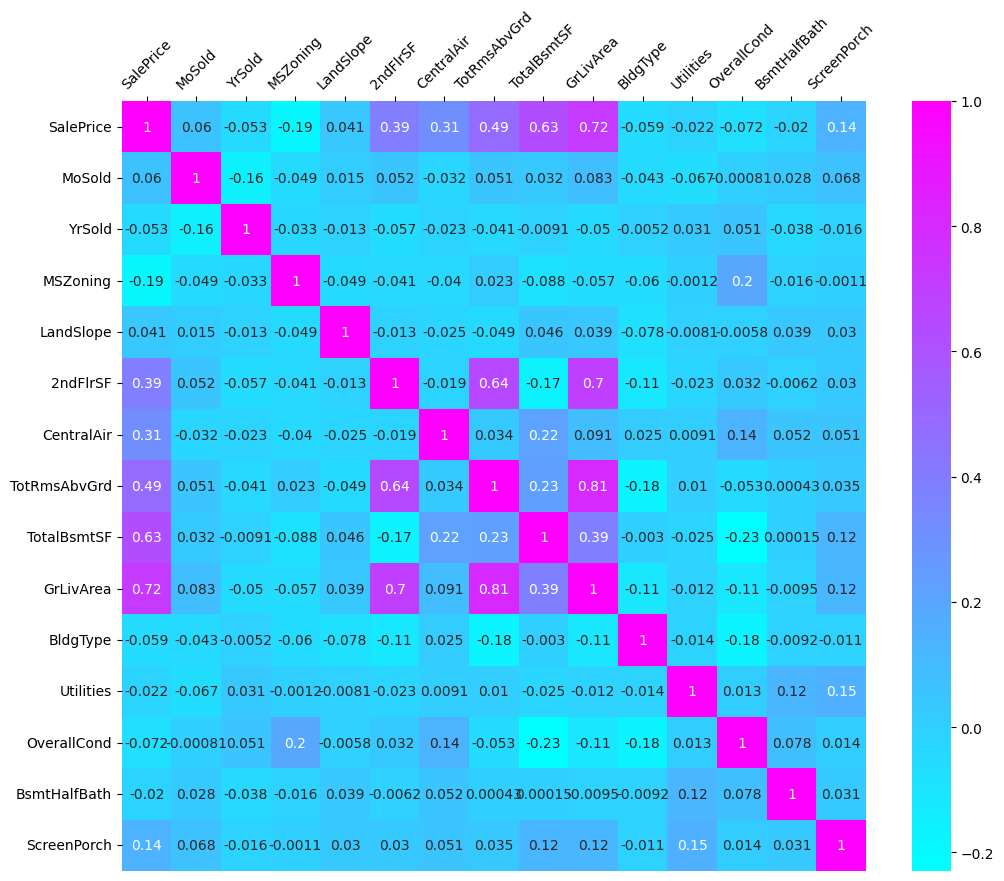

In [60]:
plt.figure(figsize=(12, 10))
cor = train_enc.corr()
g = sns.heatmap(cor, annot=True, cmap=plt.cm.cool)
g.axes.xaxis.set_ticks_position("top")
plt.setp(g.axes.get_xticklabels(), rotation=45)
plt.show()

### Linear regression (implementing models)

In [61]:
print("Feature Dimension dim:= %d" % len(feat_column))
print("Number Measurements (Training) m_{train}:= %d" % len(train))
print("Number Measurements (Training) m_{valid}:= %d" % len(valid))
print("Number Measurements (Testing)  m_{test}:= %d" % len(test))

Feature Dimension dim:= 14
Number Measurements (Training) m_{train}:= 876
Number Measurements (Training) m_{valid}:= 292
Number Measurements (Testing)  m_{test}:= 292


In [62]:
X_train = train[feat_column].values
y_train = train[target_column].values

X_valid = valid[feat_column].values
y_valid = valid[target_column].values

X_test = test[feat_column].values
y_test = test[target_column].values

Training model

In [63]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Compute AIC, AICs, BIC on training data

Compute likelihood score: $\mathcal{L}(\alpha) = - \frac{m}{2} \log{2 \pi \hat{\sigma}^2} - \frac{m}{2} $

In [64]:
def likelihood_score(y_training, y_expectation=None):
    if y_expectation is None:
        y_expectation = np.mean(y_training)
    sigma_hat = np.mean((y_training - y_expectation) ** 2)
    m = len(y_training)
    score = -0.5 * m * np.log(2 * np.pi * sigma_hat) - 0.5 * m
    return score

In [65]:
y_train_predict = model_lr.predict(X_train)
ll_score = likelihood_score(y_train, y_expectation=y_train_predict)

In [66]:
feat_dim = len(feat_column)
num_train = len(y_train)

AIC / AICs score / BIC score / R2 score / Adjusted R^2

In [67]:
AIC_score = -2 * ll_score + 2 * feat_dim
AICs_score = (
    -2 * ll_score
    + 2 * feat_dim
    + 2 * feat_dim * (feat_dim + 1) / (num_train - feat_dim - 1)
)
BIC_score = -2 * ll_score + feat_dim * np.log(num_train)
RSS_score = np.sum((y_train - y_train_predict) ** 2)
TSS_score = np.sum((y_train - np.mean(y_train)) ** 2)
R2_score = 1 - RSS_score / TSS_score
AdjustR2_score = 1 - (RSS_score / (num_train - feat_dim - 1)) / (
    TSS_score / (num_train - 1)
)

RSE

In [68]:
RSE_training = np.sqrt(RSS_score / (num_train - feat_dim))

MSE

In [69]:
MSE_training = np.mean((y_train - y_train_predict) ** 2)

In [70]:
print("Likelihood: %.4f" % -ll_score)
print("AIC  score: %.4f" % AIC_score)
print("AICs score: %.4f" % AICs_score)
print("BIC  score: %.4f" % BIC_score)
print("R2   score: %.4f" % R2_score)
print("Adjusted R2 score: %.4f" % AdjustR2_score)
print("MSE  (training)  : %.4f" % MSE_training)
print("RSE  (training)  : %.4f" % RSE_training)

Likelihood: 5131.3463
AIC  score: 10290.6926
AICs score: 10291.1804
BIC  score: 10357.5478
R2   score: 0.7387
Adjusted R2 score: 0.7345
MSE  (training)  : 7169.0289
RSE  (training)  : 85.3549


### Compute performance on testing

In [71]:
y_test_predict = model_lr.predict(X_test)

In [72]:
MSE_valid = np.mean((y_test - y_test_predict) ** 2)
RSS_valid = np.sum((y_test - y_test_predict) ** 2)
RSE_valid = np.sqrt(RSS_valid / (len(y_test) - feat_dim))

In [73]:
print("MSE (validation): %.4f" % MSE_valid)
print("RSE (validation): %.4f" % RSE_valid)

MSE (validation): 8231.5679
RSE (validation): 92.9844


## Model selection (AIC, AICs, BIC, Adjusted R2)

What is the most suitable set of features? 

In [74]:
target_column = ["SalePrice"]
feat_column_1 = ["MoSold", "YrSold"]

feat_column_2 = ["MoSold", "YrSold", "MSSubClass"]

feat_column_3 = ["MoSold", "YrSold", "MSSubClass", "LandSlope"]

feat_column_4 = ["MoSold", "YrSold", "MSSubClass", "LandSlope", "ScreenPorch"]

feat_column_5 = [
    "MoSold",
    "YrSold",
    "MSSubClass",
    "LandSlope",
    "ScreenPorch",
    "MiscVal",
]

feat_column_6 = [
    "MoSold",
    "YrSold",
    "MSSubClass",
    "LandSlope",
    "ScreenPorch",
    "MiscVal",
    "Condition1",
]

feat_column_7 = [
    "MoSold",
    "YrSold",
    "MSSubClass",
    "LandSlope",
    "ScreenPorch",
    "MiscVal",
    "Condition1",
    "OverallCond",
]

feat_column_8 = [
    "MoSold",
    "YrSold",
    "MSSubClass",
    "LandSlope",
    "ScreenPorch",
    "MiscVal",
    "Condition1",
    "OverallCond",
    "KitchenAbvGr",
]

feat_column_9 = [
    "MoSold",
    "YrSold",
    "MSSubClass",
    "LandSlope",
    "ScreenPorch",
    "MiscVal",
    "Condition1",
    "OverallCond",
    "KitchenAbvGr",
    "PoolArea",
]

feat_column_10 = [
    "MoSold",
    "YrSold",
    "MSSubClass",
    "LandSlope",
    "ScreenPorch",
    "MiscVal",
    "Condition1",
    "OverallCond",
    "KitchenAbvGr",
    "PoolArea",
    "Utilities",
]


feature_set_dict = {
    1: feat_column_1,
    2: feat_column_2,
    3: feat_column_3,
    4: feat_column_4,
    5: feat_column_5,
    6: feat_column_6,
    7: feat_column_7,
    8: feat_column_8,
    9: feat_column_9,
    10: feat_column_10,
}


In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

RMSE_training_set = {}
RMSE_validation_set = {}

AIC_training_set = {}
AICs_training_set = {}
BIC_training_set = {}
AdjustedR2_training_set = {}

R2_training_set = {}
R2_validation_set = {}

for key, feat_set in feature_set_dict.items():
    X_scaler = StandardScaler()
    train_X = X_scaler.fit_transform(train[feat_set].values[:])
    valid_X = X_scaler.transform(valid[feat_set].values[:])

    model_lr = LinearRegression()
    model_lr.fit(train_X, y_train)

    y_train_pred = model_lr.predict(train_X)
    y_valid_pred = model_lr.predict(valid_X)

    ll_score = likelihood_score(y_train, y_expectation=y_train_pred)

    num_train = len(y_train)
    feat_dim = len(feat_set)

    AIC_score = -2 * ll_score + 2 * feat_dim
    AICs_score = (
        -2 * ll_score
        + 2 * feat_dim
        + 2 * feat_dim * (feat_dim + 1) / (num_train - feat_dim - 1)
    )
    BIC_score = -2 * ll_score + feat_dim * np.log(num_train)

    RSS_score = np.sum((y_train - y_train_pred) ** 2)
    TSS_score = np.sum((y_train - np.mean(y_train)) ** 2)
    AdjustR2_score = 1 - (RSS_score / (num_train - feat_dim - 1)) / (
        TSS_score / (num_train - 1)
    )

    RSS_train = np.sum((y_train - y_train_pred) ** 2)
    RSE_train = np.sqrt(RSS_train / (len(y_train) - feat_dim))

    RSS_valid = np.sum((y_valid - y_valid_pred) ** 2)
    TSS_valid = np.sum((y_valid - np.mean(y_valid)) ** 2)
    RSE_valid = np.sqrt(RSS_valid / (len(y_valid) - feat_dim))

    RMSE_train = np.sqrt(np.mean((y_train - y_train_pred) ** 2))
    RMSE_valid = np.sqrt(np.mean((y_valid - y_valid_pred) ** 2))

    RMSE_training_set[key] = RMSE_train
    RMSE_validation_set[key] = RMSE_valid

    AIC_training_set[key] = AIC_score
    AICs_training_set[key] = AICs_score
    BIC_training_set[key] = BIC_score
    AdjustedR2_training_set[key] = AdjustR2_score


Plotting bias-variance trade-off

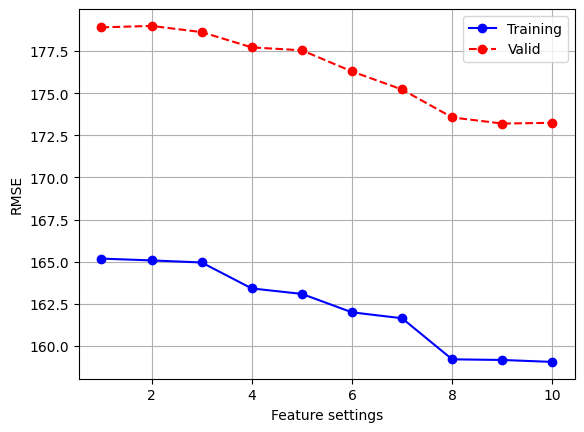

In [76]:
RMSE_training_lists = sorted(RMSE_training_set.items())
feature_set, RMSE_training = zip(*RMSE_training_lists)

RMSE_valid_lists = sorted(RMSE_validation_set.items())
feature_set, RMSE_valid = zip(*RMSE_valid_lists)

plt.plot(
    feature_set,
    RMSE_training,
    label="Training",
    color="blue",
    linestyle="-",
    marker="o",
)
plt.plot(
    feature_set, RMSE_valid, label="Valid", color="red", linestyle="--", marker="o"
)
plt.xlabel("Feature settings")
plt.ylabel("RMSE")
plt.legend()
plt.grid()
plt.show()

Plot AIC, AICs, BIC, Adjusted R2

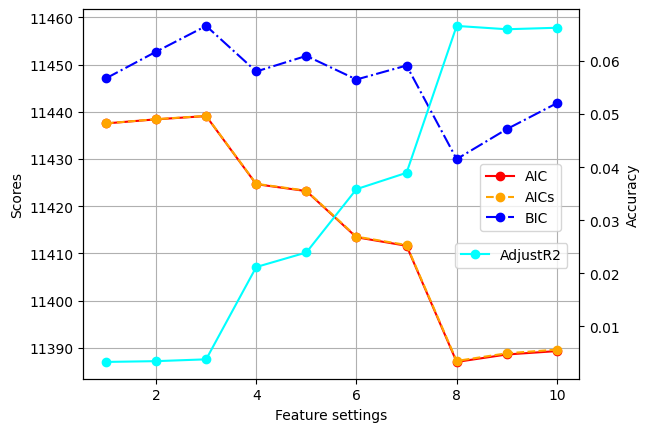

In [77]:
AIC_training_list = sorted(AIC_training_set.items())
feature_set, AIC_training = zip(*AIC_training_list)

AICs_training_list = sorted(AICs_training_set.items())
feature_set, AICs_training = zip(*AICs_training_list)

BIC_training_list = sorted(BIC_training_set.items())
feature_set, BIC_training = zip(*BIC_training_list)

AdjustedR2_training_list = sorted(AdjustedR2_training_set.items())
feature_set, AdjustedR2_training = zip(*AdjustedR2_training_list)

plt.plot(feature_set, AIC_training, label="AIC", color="red", linestyle="-", marker="o")
plt.plot(
    feature_set, AICs_training, label="AICs", color="orange", linestyle="--", marker="o"
)
plt.plot(
    feature_set, BIC_training, label="BIC", color="blue", linestyle="-.", marker="o"
)
plt.ylabel("Scores")
plt.legend(loc=(0.8, 0.4))
plt.xlabel("Feature settings")
plt.grid()

plt.gca().twinx().plot(
    feature_set,
    AdjustedR2_training,
    label="AdjustR2",
    color="cyan",
    linestyle="-",
    marker="o",
)
plt.ylabel("Accuracy")
plt.legend(loc=(0.75, 0.30))
plt.gca().xaxis.grid(True)
plt.show()